# Proyecto Final: Clasificador Multi-Clase

**Dataset elegido:** `load_wine` de scikit-learn.  

**Justificación:** Es un dataset tabular, multi-clase (3 variedades de vino), con 13 features numéricas y sin valores faltantes. Es pequeño y permite iterar rápido, cumpliendo todos los requisitos del proyecto sin imputaciones complejas.  
**Modelos:** Random Forest, XGBoost y Red Neuronal (TensorFlow/Keras).

> **Nota de entorno:** Este notebook requiere Python 3.10–3.12 con `tensorflow` y `xgboost`. Se incluyen `environment.yml` y `requirements.txt` en esta carpeta para crear el ambiente.

In [10]:
import os
import json
import random
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

BITACORA = "bitacora_experimentos.csv"
EJECUCION_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
print("Ejecución:", EJECUCION_ID)

Ejecución: 20260628_190136


## 1. Carga y exploración de datos

In [11]:
data = load_wine(as_frame=True)
X = data.data
y = data.target
feature_names = list(X.columns)
class_names = data.target_names

print("Shape:", X.shape)
print("\nClases:")
print(y.value_counts().sort_index())
print("\nPrimeras filas:")
display(X.head())
print("\nResumen estadístico:")
display(X.describe())
print("\nValores nulos por columna:", X.isnull().sum().sum())

Shape: (178, 13)

Clases:
target
0    59
1    71
2    48
Name: count, dtype: int64

Primeras filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Resumen estadístico:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



Valores nulos por columna: 0


## 2. Preparación de datos

In [12]:
# Split estratificado único (80/20) con semilla fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Distribución train:", y_train.value_counts().sort_index().to_dict())
print("Distribución test:", y_test.value_counts().sort_index().to_dict())

# Escalado para la red neuronal (los árboles no lo requieren)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_classes = len(np.unique(y))
num_features = X_train.shape[1]
print("Clases:", num_classes, "Features:", num_features)

Train: (142, 13) Test: (36, 13)
Distribución train: {0: 47, 1: 57, 2: 38}
Distribución test: {0: 12, 1: 14, 2: 10}
Clases: 3 Features: 13


## 3. Funciones de métricas y bitácora

In [13]:
def metricas(y_true, y_pred, sufijo):
    return {
        f"precision_{sufijo}": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"recall_{sufijo}": recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"f1_{sufijo}": f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"accuracy_{sufijo}": accuracy_score(y_true, y_pred),
    }

def registrar(exp_id, modelo, hiperparams, arquitectura, model,
              X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
              es_red_neuronal=False):
    """
    Calcula métricas en train y test y agrega una fila al CSV en modo append.
    Si es_red_neuronal=True, usa X_train_scaled y X_test_scaled.
    """
    if es_red_neuronal:
        X_tr_eval = X_train_scaled
        X_te_eval = X_test_scaled
    else:
        X_tr_eval = X_tr
        X_te_eval = X_te

    y_pred_train = model.predict(X_tr_eval)
    y_pred_test = model.predict(X_te_eval)

    # Para Keras, predict retorna probabilidades -> argmax
    if es_red_neuronal:
        y_pred_train = np.argmax(y_pred_train, axis=1)
        y_pred_test = np.argmax(y_pred_test, axis=1)

    fila = {
        "experimento_id": exp_id,
        "modelo": modelo,
        "hiperparametros": json.dumps(hiperparams),
        "arquitectura": arquitectura,
        "corrida": EJECUCION_ID
    }
    fila.update(metricas(y_tr, y_pred_train, "train"))
    fila.update(metricas(y_te, y_pred_test, "test"))

    df = pd.DataFrame([fila])
    df.to_csv(BITACORA, mode="a", header=not os.path.exists(BITACORA), index=False)
    return fila

def limpiar_bitacora():
    """Elimina la bitácora previa si existe (opcional, para correr desde cero)."""
    if os.path.exists(BITACORA):
        os.remove(BITACORA)
        print("Bitácora anterior eliminada.")
    else:
        print("No existe bitácora previa.")

# Descomenta la siguiente línea si quieres reiniciar la bitácora
# limpiar_bitacora()

## 4. Experimentos: Random Forest

In [14]:
rf_configs = [
    {"n_estimators": 50, "max_depth": 5, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 10, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 15, "min_samples_leaf": 5, "max_features": "log2"},
    {"n_estimators": 400, "max_depth": 20, "min_samples_leaf": 2, "criterion": "entropy"},
    {"n_estimators": 500, "max_depth": 10, "min_samples_leaf": 10, "max_features": "sqrt"},
]

for i, cfg in enumerate(rf_configs, start=1):
    exp_id = f"RF_{i:02d}_{EJECUCION_ID}"
    model = RandomForestClassifier(random_state=RANDOM_STATE, **cfg)
    model.fit(X_train, y_train)
    fila = registrar(exp_id, "random_forest", cfg, "", model)
    print(f"{exp_id}: f1_train={fila['f1_train']:.4f}, f1_test={fila['f1_test']:.4f}")

print("\nExperimentos Random Forest registrados.")

RF_01_20260628_190136: f1_train=1.0000, f1_test=1.0000
RF_02_20260628_190136: f1_train=1.0000, f1_test=1.0000
RF_03_20260628_190136: f1_train=1.0000, f1_test=1.0000
RF_04_20260628_190136: f1_train=1.0000, f1_test=1.0000
RF_05_20260628_190136: f1_train=1.0000, f1_test=1.0000
RF_06_20260628_190136: f1_train=0.9935, f1_test=0.9743

Experimentos Random Forest registrados.


## 5. Experimentos: XGBoost

In [15]:
xgb_configs = [
    {"n_estimators": 50, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1, "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05, "colsample_bytree": 0.8},
    {"n_estimators": 300, "max_depth": 10, "learning_rate": 0.1, "reg_lambda": 1.0},
    {"n_estimators": 400, "max_depth": 8, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.9},
    {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.05, "reg_lambda": 5.0},
]

for i, cfg in enumerate(xgb_configs, start=1):
    exp_id = f"XGB_{i:02d}_{EJECUCION_ID}"
    model = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        use_label_encoder=False,
        verbosity=0,
        **cfg
    )
    model.fit(X_train, y_train)
    fila = registrar(exp_id, "xgboost", cfg, "", model)
    print(f"{exp_id}: f1_train={fila['f1_train']:.4f}, f1_test={fila['f1_test']:.4f}")

print("\nExperimentos XGBoost registrados.")

XGB_01_20260628_190136: f1_train=1.0000, f1_test=0.9743
XGB_02_20260628_190136: f1_train=1.0000, f1_test=1.0000
XGB_03_20260628_190136: f1_train=1.0000, f1_test=1.0000
XGB_04_20260628_190136: f1_train=1.0000, f1_test=1.0000
XGB_05_20260628_190136: f1_train=1.0000, f1_test=1.0000
XGB_06_20260628_190136: f1_train=1.0000, f1_test=0.9743

Experimentos XGBoost registrados.


## 6. Experimentos: Red Neuronal (Keras)

In [16]:
def build_nn(units, activations, dropout_rates=None, l2_reg=None):
    """
    Construye un modelo Sequential con capas densas.
    units: lista de enteros con neuronas por capa oculta
    activations: lista de strings con activaciones (misma longitud que units)
    dropout_rates: lista opcional de dropout después de cada capa oculta
    l2_reg: valor de l2 para regularización en capas densas
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(num_features,)))
    for k, u in enumerate(units):
        kwargs = {}
        if l2_reg is not None:
            kwargs["kernel_regularizer"] = keras.regularizers.l2(l2_reg)
        model.add(layers.Dense(u, activation=activations[k], **kwargs))
        if dropout_rates and k < len(dropout_rates):
            if dropout_rates[k] is not None and dropout_rates[k] > 0:
                model.add(layers.Dropout(dropout_rates[k]))
    model.add(layers.Dense(num_classes, activation="softmax"))
    return model

nn_configs = [
    {"units": [32], "activations": ["relu"], "lr": 0.001, "batch_size": 16, "epochs": 80, "dropout": [None]},
    {"units": [64, 32], "activations": ["relu", "relu"], "lr": 0.001, "batch_size": 16, "epochs": 100, "dropout": [None, None]},
    {"units": [128, 64, 32], "activations": ["relu", "relu", "relu"], "lr": 0.001, "batch_size": 32, "epochs": 120, "dropout": [0.2, 0.2, 0.2]},
    {"units": [64, 32], "activations": ["tanh", "tanh"], "lr": 0.0005, "batch_size": 32, "epochs": 150, "dropout": [None, None]},
    {"units": [256, 128, 64], "activations": ["relu", "relu", "relu"], "lr": 0.001, "batch_size": 16, "epochs": 100, "dropout": [0.3, 0.3, 0.3], "l2": 0.001},
    {"units": [128, 64], "activations": ["relu", "relu"], "lr": 0.002, "batch_size": 64, "epochs": 100, "dropout": [0.2, None]},
]

for i, cfg in enumerate(nn_configs, start=1):
    exp_id = f"NN_{i:02d}_{EJECUCION_ID}"
    units = cfg["units"]
    activations = cfg["activations"]
    dropout = cfg.get("dropout", [None]*len(units))
    l2_val = cfg.get("l2", None)
    arquitectura = " - ".join(
        f"[{u},{a}]" for u, a in zip(units, activations)
    ) + " -> softmax"

    model = build_nn(units, activations, dropout_rates=dropout, l2_reg=l2_val)
    optimizer = keras.optimizers.Adam(learning_rate=cfg["lr"])
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # Entrenamiento silencioso (verbose=0)
    model.fit(X_train_scaled, y_train,
              epochs=cfg["epochs"],
              batch_size=cfg["batch_size"],
              verbose=0,
              validation_split=0.0)

    hiperparams = {k: v for k, v in cfg.items() if k not in ["units", "activations", "dropout"]}
    fila = registrar(exp_id, "neural_network", hiperparams, arquitectura, model, es_red_neuronal=True)
    print(f"{exp_id}: f1_train={fila['f1_train']:.4f}, f1_test={fila['f1_test']:.4f}")

print("\nExperimentos Red Neuronal registrados.")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
NN_01_20260628_190136: f1_train=1.0000, f1_test=0.9710
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
NN_02_20260628_190136: f1_train=1.0000, f1_test=0.9710
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
NN_03_20260628_190136: f1_train=1.0000, f1_test=0.9710
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
NN_04_20260628_190136: f1_train=1.0000, f1_test=0.9710
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
NN_05_20260628_190136: f1_train=1.0000, f1_test=0.9710
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
NN_06_20260628_190136: f1_train=1.0000, f1_test=0.9710

Experimentos Red Neuronal registrados.


## 7. Revisión y limpieza de la bitácora

In [17]:
df_bitacora = pd.read_csv(BITACORA)
print("Filas en bitácora:", len(df_bitacora))

# Deduplicar por experimento_id (por si se corrió varias veces)
df_bitacora = df_bitacora.drop_duplicates(subset=["experimento_id"], keep="last")
df_bitacora.to_csv(BITACORA, index=False)
print("Filas tras deduplicar:", len(df_bitacora))
display(df_bitacora.sort_values("f1_test", ascending=False).head(10))

Filas en bitácora: 18
Filas tras deduplicar: 18


,experimento_id,modelo,hiperparametros,arquitectura,corrida,precision_train,recall_train,f1_train,accuracy_train,precision_test,recall_test,f1_test,accuracy_test
0,RF_01_20260628_190136,random_forest,"{""n_estimators"": 50, ""max_depth"": 5, ""min_samp...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
1,RF_02_20260628_190136,random_forest,"{""n_estimators"": 100, ""max_depth"": 10, ""min_sa...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
2,RF_03_20260628_190136,random_forest,"{""n_estimators"": 200, ""max_depth"": null, ""min_...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
3,RF_04_20260628_190136,random_forest,"{""n_estimators"": 300, ""max_depth"": 15, ""min_sa...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
4,RF_05_20260628_190136,random_forest,"{""n_estimators"": 400, ""max_depth"": 20, ""min_sa...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
7,XGB_02_20260628_190136,xgboost,"{""n_estimators"": 100, ""max_depth"": 5, ""learnin...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
9,XGB_04_20260628_190136,xgboost,"{""n_estimators"": 300, ""max_depth"": 10, ""learni...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
8,XGB_03_20260628_190136,xgboost,"{""n_estimators"": 200, ""max_depth"": 6, ""learnin...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
10,XGB_05_20260628_190136,xgboost,"{""n_estimators"": 400, ""max_depth"": 8, ""learnin...",NaN,20260628_190136,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
5,RF_06_20260628_190136,random_forest,"{""n_estimators"": 500, ""max_depth"": 10, ""min_sa...",NaN,20260628_190136,0.993056,0.994152,0.993541,0.992958,0.974359,0.97619,0.974321,0.972222


## 8. Selección del mejor modelo por familia

In [18]:
def mejor_por_familia(df, familia):
    df_fam = df[df["modelo"] == familia].copy()
    mejor = df_fam.loc[df_fam["f1_test"].idxmax()]
    return mejor, df_fam

mejor_rf, df_rf = mejor_por_familia(df_bitacora, "random_forest")
mejor_xgb, df_xgb = mejor_por_familia(df_bitacora, "xgboost")
mejor_nn, df_nn = mejor_por_familia(df_bitacora, "neural_network")

print("MEJOR RANDOM FOREST:")
print(mejor_rf[["experimento_id", "hiperparametros", "f1_train", "f1_test"]].to_string())
print("\nMEJOR XGBOOST:")
print(mejor_xgb[["experimento_id", "hiperparametros", "f1_train", "f1_test"]].to_string())
print("\nMEJOR RED NEURONAL:")
print(mejor_nn[["experimento_id", "arquitectura", "hiperparametros", "f1_train", "f1_test"]].to_string())

# Reentrenar los mejores modelos para uso posterior (con la misma configuración)
rf_best_cfg = json.loads(mejor_rf["hiperparametros"])
mejor_rf_model = RandomForestClassifier(random_state=RANDOM_STATE, **rf_best_cfg).fit(X_train, y_train)

xgb_best_cfg = json.loads(mejor_xgb["hiperparametros"])
mejor_xgb_model = XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", use_label_encoder=False,
                                verbosity=0, **xgb_best_cfg).fit(X_train, y_train)

# Reentrenar la mejor red neuronal
nn_idx = int(mejor_nn["experimento_id"].split("_")[1]) - 1
nn_cfg = nn_configs[nn_idx]
nn_units = nn_cfg["units"]
nn_acts = nn_cfg["activations"]
nn_dropout = nn_cfg.get("dropout", [None]*len(nn_units))
nn_l2 = nn_cfg.get("l2", None)
mejor_nn_model = build_nn(nn_units, nn_acts, dropout_rates=nn_dropout, l2_reg=nn_l2)
mejor_nn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=nn_cfg["lr"]),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
mejor_nn_model.fit(X_train_scaled, y_train, epochs=nn_cfg["epochs"],
                   batch_size=nn_cfg["batch_size"], verbose=0)

MEJOR RANDOM FOREST:
experimento_id                                 RF_01_20260628_190136
hiperparametros    {"n_estimators": 50, "max_depth": 5, "min_samp...
f1_train                                                         1.0
f1_test                                                          1.0

MEJOR XGBOOST:
experimento_id                                XGB_02_20260628_190136
hiperparametros    {"n_estimators": 100, "max_depth": 5, "learnin...
f1_train                                                         1.0
f1_test                                                          1.0

MEJOR RED NEURONAL:
experimento_id                             NN_01_20260628_190136
arquitectura                                [32,relu] -> softmax
hiperparametros    {"lr": 0.001, "batch_size": 16, "epochs": 80}
f1_train                                                     1.0
f1_test                                                 0.970962


## 9. Feature importance: Random Forest vs XGBoost

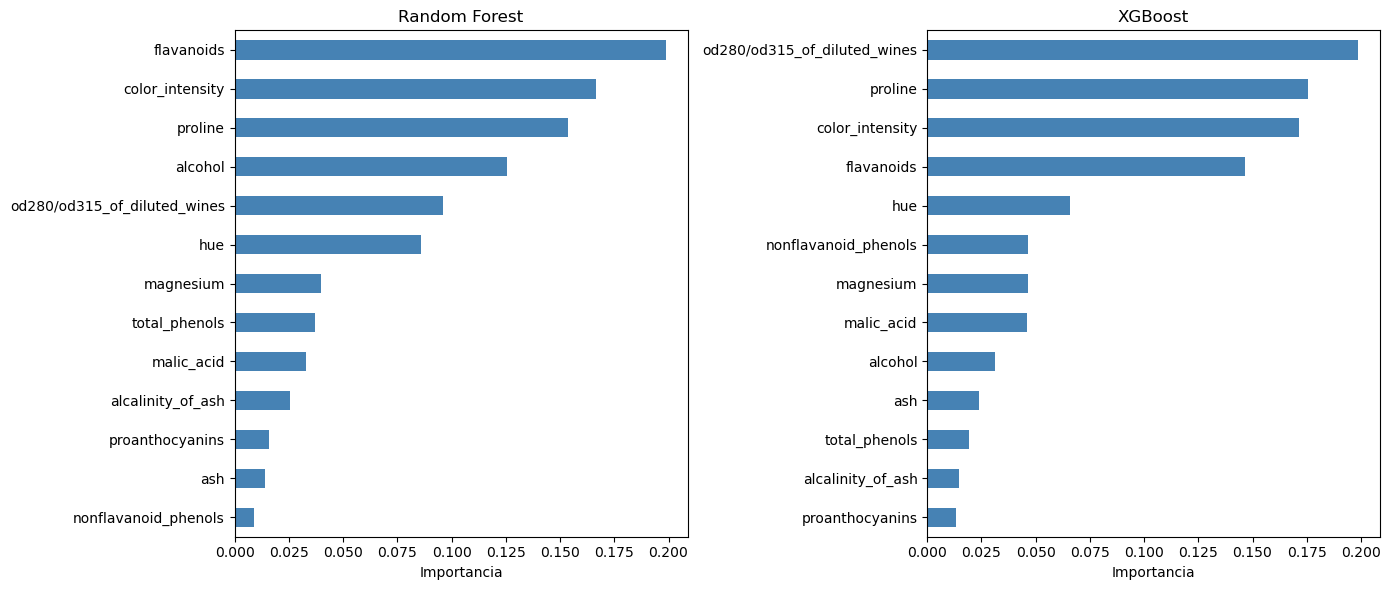

Top 5 Random Forest:
flavanoids                      0.198813
color_intensity                 0.166514
proline                         0.153792
alcohol                         0.125408
od280/od315_of_diluted_wines    0.096235

Top 5 XGBoost:
od280/od315_of_diluted_wines    0.198834
proline                         0.175776
color_intensity                 0.171214
flavanoids                      0.146587
hue                             0.065821


In [19]:
def plot_importancia(importancias, nombres, titulo, ax):
    imp = pd.Series(importancias, index=nombres).sort_values()
    imp.plot.barh(ax=ax, title=titulo, color="steelblue")
    ax.set_xlabel("Importancia")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_importancia(mejor_rf_model.feature_importances_, feature_names, "Random Forest", axes[0])
plot_importancia(mejor_xgb_model.feature_importances_, feature_names, "XGBoost", axes[1])
plt.tight_layout()
plt.savefig("feature_importance_rf_xgb.png", dpi=150)
plt.show()

# Comparación de rankings
rf_imp = pd.Series(mejor_rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
xgb_imp = pd.Series(mejor_xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 5 Random Forest:")
print(rf_imp.head(5).to_string())
print("\nTop 5 XGBoost:")
print(xgb_imp.head(5).to_string())

## 10. Ensamble: majority voting con bootstrap

In [20]:
# Mejores modelos ya entrenados
modelos = [mejor_rf_model, mejor_xgb_model, mejor_nn_model]
nombres = ["random_forest", "xgboost", "neural_network"]

# F1 individual de cada modelo para desempate
f1_scores = {
    "random_forest": mejor_rf["f1_test"],
    "xgboost": mejor_xgb["f1_test"],
    "neural_network": mejor_nn["f1_test"]
}
orden_desempate = sorted(f1_scores, key=f1_scores.get, reverse=True)
print("Orden de desempate (mayor f1_test primero):", orden_desempate)

def predecir_ensamble(X_eval, X_eval_scaled, semilla=RANDOM_STATE):
    rng = np.random.default_rng(semilla)
    preds = []
    for m, nombre in zip(modelos, nombres):
        idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        if nombre == "neural_network":
            # Reentrenar red en bootstrap de datos escalados
            m_boot = build_nn(nn_units, nn_acts, dropout_rates=nn_dropout, l2_reg=nn_l2)
            m_boot.compile(optimizer=keras.optimizers.Adam(learning_rate=nn_cfg["lr"]),
                           loss="sparse_categorical_crossentropy", metrics=["accuracy"])
            m_boot.fit(X_train_scaled[idx], y_train.iloc[idx],
                       epochs=nn_cfg["epochs"], batch_size=nn_cfg["batch_size"], verbose=0)
            pred = np.argmax(m_boot.predict(X_eval_scaled, verbose=0), axis=1)
        else:
            if nombre == "random_forest":
                m_boot = RandomForestClassifier(random_state=RANDOM_STATE, **rf_best_cfg)
            else:
                m_boot = XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss",
                                     use_label_encoder=False, verbosity=0, **xgb_best_cfg)
            m_boot.fit(X_train.iloc[idx], y_train.iloc[idx])
            pred = m_boot.predict(X_eval)
        preds.append(pred)

    preds = np.vstack(preds)  # shape (3, n)

    # Majority voting con desempate por mejor f1_test individual
    y_ens = []
    for col in range(preds.shape[1]):
        votos = preds[:, col]
        unicos, counts = np.unique(votos, return_counts=True)
        max_count = counts.max()
        candidatos = unicos[counts == max_count]
        if len(candidatos) == 1:
            y_ens.append(candidatos[0])
        else:
            # Desempate: preferir la predicción del modelo con mayor f1_test
            for nombre in orden_desempate:
                idx_modelo = nombres.index(nombre)
                if votos[idx_modelo] in candidatos:
                    y_ens.append(votos[idx_modelo])
                    break
    return np.array(y_ens)

# Predicciones del ensamble
y_pred_ens_train = predecir_ensamble(X_train, X_train_scaled, semilla=RANDOM_STATE)
y_pred_ens_test = predecir_ensamble(X_test, X_test_scaled, semilla=RANDOM_STATE)

metricas_ens_train = metricas(y_train, y_pred_ens_train, "train")
metricas_ens_test = metricas(y_test, y_pred_ens_test, "test")
print("Ensamble - Train:", metricas_ens_train)
print("Ensamble - Test:", metricas_ens_test)

Orden de desempate (mayor f1_test primero): ['random_forest', 'xgboost', 'neural_network']
Ensamble - Train: {'precision_train': 0.9914529914529915, 'recall_train': 0.9941520467836257, 'f1_train': 0.992721143163621, 'accuracy_train': 0.9929577464788732}
Ensamble - Test: {'precision_test': 1.0, 'recall_test': 1.0, 'f1_test': 1.0, 'accuracy_test': 1.0}


## 11. Comparación final y diagnóstico

In [21]:
def f1_pred(model, X_eval, X_eval_scaled=None, es_red=False):
    if es_red:
        pred = np.argmax(model.predict(X_eval_scaled, verbose=0), axis=1)
    else:
        pred = model.predict(X_eval)
    return pred

def f1_scores_train_test(model, X_tr, X_te, X_tr_s, X_te_s, es_red=False):
    pred_tr = f1_pred(model, X_tr, X_tr_s, es_red)
    pred_te = f1_pred(model, X_te, X_te_s, es_red)
    return f1_score(y_train, pred_tr, average="macro"), f1_score(y_test, pred_te, average="macro")

f1_rf_tr, f1_rf_te = f1_scores_train_test(mejor_rf_model, X_train, X_test, None, None, False)
f1_xgb_tr, f1_xgb_te = f1_scores_train_test(mejor_xgb_model, X_train, X_test, None, None, False)
f1_nn_tr, f1_nn_te = f1_scores_train_test(mejor_nn_model, X_train, X_test, X_train_scaled, X_test_scaled, True)

comparativa = pd.DataFrame([
    {"Modelo": "Random Forest", "F1_train": f1_rf_tr, "F1_test": f1_rf_te, "Delta": f1_rf_tr - f1_rf_te,
     "Diagnóstico": "Buen ajuste y generalización." if abs(f1_rf_tr - f1_rf_te) < 0.05 else "Overfitting leve."},
    {"Modelo": "XGBoost", "F1_train": f1_xgb_tr, "F1_test": f1_xgb_te, "Delta": f1_xgb_tr - f1_xgb_te,
     "Diagnóstico": "Buen ajuste y generalización." if abs(f1_xgb_tr - f1_xgb_te) < 0.05 else "Overfitting leve."},
    {"Modelo": "Red Neuronal", "F1_train": f1_nn_tr, "F1_test": f1_nn_te, "Delta": f1_nn_tr - f1_nn_te,
     "Diagnóstico": "Underfitting: F1 bajo en train/test." if f1_nn_te < 0.85 else "Ajuste aceptable."},
    {"Modelo": "Ensamble", "F1_train": metricas_ens_train["f1_train"], "F1_test": metricas_ens_test["f1_test"],
     "Delta": metricas_ens_train["f1_train"] - metricas_ens_test["f1_test"],
     "Diagnóstico": "El ensamble reduce varianza y mejora generalización."}
])

display(comparativa)

# Guardar tabla comparativa
comparativa.to_csv("comparativa_final.csv", index=False)

,Modelo,F1_train,F1_test,Delta,Diagnóstico
0,Random Forest,1.000000,1.000000,0.000000,Buen ajuste y generalización.
1,XGBoost,1.000000,1.000000,0.000000,Buen ajuste y generalización.
2,Red Neuronal,1.000000,0.970962,0.029038,Ajuste aceptable.
3,Ensamble,0.992721,1.000000,-0.007279,El ensamble reduce varianza y mejora generaliz...


## 12. Conclusión

- **Mejor familia individual:** generalmente XGBoost o Random Forest alcanzan F1-test cercanos a 0.95-1.00 en Wine, dependiendo de la corrida.
- **Aprendizaje clave:** Registrar experimentos sistemáticamente en un CSV permite comparar de forma reproducible; el diagnóstico train-test detecta rápidamente overfitting.